# Example 1: Sigma Interval Ambiguity (Section 5.1)

Robust superhedging of a digital call payoff under the volatility-interval
ambiguity set $\mathcal{P} = \{P^\sigma : \sigma \in [\sigma_{lo},\sigma_{hi}]\}$
of Section 5.1 of the paper. The ambiguity is non-rectangular because all
transition kernels must share a single global $\sigma$.


## Introduction


---

### Model setup

Defines a price process with **unknown constant volatility**:
$$
S_{t+1} = S_t + \mu + \sigma \varepsilon_{t+1}, \quad \varepsilon_{t+1} \in \{-1,+1\}
$$

- $\sigma$ is fixed over time but unknown:
$$
\sigma \in [\sigma_{\min}, \sigma_{\max}]
$$

---

### Ambiguity set

Nonrectangular uncertainty:
$$
\mathcal{P}^{nr} = \{ P^\sigma : \sigma \in [\sigma_{\min}, \sigma_{\max}] \}
$$

---

### Payoff

Digital option:
$$
\zeta = \mathbf{1}_{\{S_T \ge K\}}
$$

---

### Methods compared

- $\pi_{LP}$: exact robust superhedging (LP)
- $\pi_R$: rectangular dynamic programming
- $\pi_{NR}$: actor–critic approximation

---

### Key insight

- Nonrectangular uncertainty comes from **single global parameter $\sigma$**
- Rectangular model allows $\sigma_t$ to vary over time




### Imports

Loads libraries for:
- numerical computation (`numpy`)
- optimization (`cvxpy`)
- plotting (`matplotlib`)
- utilities (`itertools`, `time`)

---

### Inputs
- None

---

### Outputs
- Conceptual setup for Example 5.1
- Loaded Python modules

In [14]:
import itertools
import time
import numpy as np
import cvxpy as cp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Parameters


### 1. Market model

Sets parameters for:
$$
S_{t+1} = S_t + \mu + \sigma \varepsilon_{t+1}
$$

- $\mu$: drift  
- $\sigma \in [\sigma_{\min}, \sigma_{\max}]$ (unknown, constant)  
- $T$: time horizon  
- $S_0$: initial price  
- $K$: strike  

Also defines $M$ discrete volatility levels for the LP benchmark.

---

### 2. Discretization

- Action space:
$$
a \in A_{\text{grid}}
$$

- Wealth grid:
$$
w \in W_{\text{grid}}
$$

Chosen to cover all reachable wealth values.

---

### 3. Actor–critic parameters

Controls:
- number of iterations
- policy step size $\eta$
- Monte Carlo sample sizes
- policy averaging weight

---

### Inputs
- None (fixed parameters)

---

### Outputs
- model parameters ($\mu$, $\sigma$ range, $T$, $S_0$, $K$)
- discretization grids ($A_{\text{grid}}$, $W_{\text{grid}}$)
- algorithm hyperparameters
- sizes: $|A| = \texttt{NA}$, $|W| = \texttt{NW}$

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# PARAMETERS
# ═══════════════════════════════════════════════════════════════════════════════

np.random.seed(0)

# ── Market model ─────────────────────────────────────────────────────────────
MU        = 0.02
T         = 3
K_STRIKE  = 1.05
S0        = 1.0

# ── Ambiguity set (Section 5.1: sigma in [sigma_lo, sigma_hi]) ───────────────
SIGMA_LO  = 0.06
SIGMA_HI  = 0.14
N_SIGMA   = 6          # discretisation level M of [sigma_lo, sigma_hi] for LP

# ── MDP discretisation ───────────────────────────────────────────────────────
A_GRID = np.linspace(-2.0, 2.0, 13)
W_GRID = np.linspace(-1.0, 2.0, 31)

# ── Actor-critic hyper-parameters ────────────────────────────────────────────
N_AC_ITERS  = 80
ETA_ACTOR   = 0.05    # policy-gradient step size           [tune: 0.01–0.20]
N_MC_GRAD   = 150     # MC samples for critic F estimation  [generous; cheap]
N_MC_Q      = 80      # MC samples per (state, action) for Q  [tune: 20–200]
POLICY_EMA  = 0.15    # EMA weight on new iterate           [tune: 0.05–0.30]

NA = len(A_GRID)
NW = len(W_GRID)


## Data Generation

Generates all sample paths for the **sigma-grid ambiguity** and computes payoffs and increments.


### 1. Path generation

Enumerates all combinations of:
- volatility levels $\sigma^m \in \{\sigma^1,\dots,\sigma^M\}$
- sign sequences $\varepsilon_t \in \{-1,+1\}$

Constructs paths via:
$$
S_{t+1} = S_t + \mu + \sigma \varepsilon_{t+1}
$$

---

### 2. Payoff and increments

- Digital payoff:
$$
\zeta = \mathbf{1}_{\{S_T \ge K\}}
$$

- Price increments:
$$
\Delta S_t = S_{t+1} - S_t
$$

---

### 3. Diagnostics

Checks:
- number of paths:
$$
N = M \cdot 2^T
$$
- fraction of paths with payoff
- whether wealth grid $W_{\text{grid}}$ covers extreme values

---

### Inputs
- $\mu$, $\sigma_{\min}$, $\sigma_{\max}$, $T$, $S_0$, $K$
- $N_\sigma$, $A_{\text{grid}}$, $W_{\text{grid}}$

---

### Outputs
- `paths`: all simulated paths
- $N$: number of paths
- `payoffs`: digital payoff per path
- `ds`: price increments

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA
# ═══════════════════════════════════════════════════════════════════════════════
#
# Path generation matches Section 5.1: for each sigma on a discretisation grid,
# enumerate all 2^T sign sequences (eps_t in {-1, +1}). The resulting paths
# enumerate the support of every model P^sigma in the discretised ambiguity set.

def generate_paths():
    sigma_grid = np.linspace(SIGMA_LO, SIGMA_HI, N_SIGMA)
    sign_seqs  = list(itertools.product([-1, 1], repeat=T))

    paths_, sigma_labels_ = [], []
    for sigma in sigma_grid:
        for signs in sign_seqs:
            s = [S0]
            for eps in signs:
                s.append(s[-1] + MU + sigma * eps)
            paths_.append(s)
            sigma_labels_.append(sigma)
    return np.array(paths_), np.array(sigma_labels_), sign_seqs

paths, sigma_labels, sign_seqs = generate_paths()
N = len(paths)

ds      = np.diff(paths, axis=1)
payoffs = (paths[:, -1] >= K_STRIKE).astype(float)

# ── Startup diagnostics ──────────────────────────────────────────────────────
print(f"N = {N} paths  ({N_SIGMA} sigmas x {2**T} sign sequences)")
print(f"Digital payoff: {int(payoffs.sum())}/{N} paths pay out  "
      f"(fraction = {payoffs.mean():.3f})")
_w_extreme = T * SIGMA_HI * float(np.max(np.abs(A_GRID)))
print(f"Wealth range diagnostic: [{-_w_extreme:.3f}, {_w_extreme:.3f}]  "
      f"vs W_GRID: [{W_GRID[0]:.3f}, {W_GRID[-1]:.3f}]")
if -_w_extreme < W_GRID[0] or _w_extreme > W_GRID[-1]:
    print("  *** WARNING: W_GRID may be too narrow — widen it ***")
else:
    print("  W_GRID coverage: OK")
print(f"|A_GRID|={NA}  |W_GRID|={NW}")


N = 48 paths  (6 sigmas x 8 sign sequences)
Digital payoff: 24/48 paths pay out  (fraction = 0.500)
Wealth range diagnostic: [-0.840, 0.840]  vs W_GRID: [-1.000, 2.000]
  W_GRID coverage: OK
|A_GRID|=13  |W_GRID|=31


## Path Structure

For every observed path $i$ at every time $t$, we record:

1. **Consistent set** $C_t(i) = \{j : (\sigma^{(j)}, h_t(j)) = (\sigma^{(i)}, h_t(i))\}$ —
   the set of paths sharing both the volatility label and the price prefix at time $t$.
   This is what predictability of the hedging strategy enforces: two paths with the
   same observable history must use the same hedge.

2. **Unique history nodes** at each time: a deduplicated list of consistent sets,
   used by the LP and the actor-critic to share decision variables / policies.

The $\sigma$-label is part of the key because two paths with the same price
prefix but different $\sigma$ live in different members of the ambiguity set
$\{P^\sigma\}_\sigma$ and therefore in disjoint subtrees of the LP.


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONSISTENT SETS  &  UNIQUE NODES
# ═══════════════════════════════════════════════════════════════════════════════

PREC = 8

# Consistent set: paths sharing (sigma_label, prefix) at time t.
_consistent = {}
for i in range(N):
    for t in range(T):
        key_i = (round(float(sigma_labels[i]), PREC),
                 tuple(np.round(paths[i, :t + 1], PREC)))
        _consistent[(i, t)] = [
            j for j in range(N)
            if (round(float(sigma_labels[j]), PREC),
                tuple(np.round(paths[j, :t + 1], PREC))) == key_i
        ]

# Unique consistent sets per time step
_unique_nodes = {}
for t in range(T):
    seen = {}
    for i in range(N):
        key = frozenset(_consistent[(i, t)])
        if key not in seen:
            seen[key] = i
    _unique_nodes[t] = [(rep_i, list(C)) for C, rep_i in seen.items()]

for t in range(T):
    sizes = sorted(set(len(C) for _, C in _unique_nodes[t]))
    print(f"  t={t}: {len(_unique_nodes[t])} unique history nodes  "
          f"(consistent set sizes: {sizes})")


  t=0: 6 unique history nodes  (consistent set sizes: [8])
  t=1: 12 unique history nodes  (consistent set sizes: [4])
  t=2: 24 unique history nodes  (consistent set sizes: [2])


## Utility Functions

### 1. Wealth discretization

Maps continuous wealth to grid points:

- `nearest_w`: scalar version  
- `nearest_w_batch`: vectorized version  

$$
w \;\mapsto\; \arg\min_{w_i \in W_{\text{grid}}} |w - w_i|
$$

Used to keep the state space finite.

---

### 2. Simplex projection

Projects a vector onto the probability simplex:
$$
\Pi_{\Delta}(v) = \arg\min_{p \in \Delta} \|p - v\|_2^2
$$

Ensures policy vectors satisfy:
$$
p_a \ge 0, \quad \sum_a p_a = 1
$$

---

### Inputs
- `W_GRID`, `NW`
- vector $v$

---

### Outputs
- nearest grid indices
- projected probability vector

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# UTILITY FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def nearest_w(w):
    return int(np.clip(np.argmin(np.abs(W_GRID - w)), 0, NW - 1))


def nearest_w_batch(w_arr):
    """Vectorised nearest-W index, any shape."""
    return np.argmin(np.abs(w_arr[..., None] - W_GRID), axis=-1).clip(0, NW - 1)


def project_simplex(v):
    """Euclidean projection onto the probability simplex (Duchi et al. 2008)."""
    n   = len(v)
    u   = np.sort(v)[::-1]
    css = np.cumsum(u)
    idx = np.where(u > (css - 1.0) / (np.arange(n) + 1))[0][-1]
    return np.maximum(v - (css[idx] - 1.0) / (idx + 1), 0.0)


## LP Benchmark

Computes the **exact robust superhedging price** for the sigma-interval model via a linear program:
$$
\pi_{LP}
$$

---

### 1. Hedging nodes

Constructs nodes:
$$
(\sigma, S_0,\dots,S_t)
$$

- Paths sharing the same history within a fixed $\sigma$ share one hedge variable
- Different $\sigma$ → always distinct nodes

Ensures **predictable strategies**.

---

### 2. Linear program

Solves:
$$
\min_x \quad x
$$

subject to:
$$
x + \sum_{t=0}^{T-1} h_t(\sigma,\text{history})\,\Delta S_{t+1}
\ge \zeta
$$

for all paths $(\sigma^m, \omega)$

---

### 3. Interpretation

- Enforces hedging across **all volatility levels simultaneously**
- Fully captures **nonrectangular uncertainty**

---

### Inputs
- `paths`, `ds`, `payoffs`
- `sigma_labels`
- $T$

---

### Outputs
- $\pi_{LP}$: exact robust superhedging price

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.  LP BENCHMARK  pi_LP   (non-rectangular sigma-interval, eq. 21)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Exact pathwise robust superhedging LP under the sigma-interval ambiguity:
#
#     min   x
#     s.t.  x + sum_t H_t(node(i,t)) * Delta S_{t+1}^(i)  >=  payoff^(i),  for all i
#
# Two paths share a hedge variable at time t iff they share both the volatility
# label and the price prefix at t — i.e. iff they belong to the same consistent
# set _consistent[(i, t)]. Predictability is enforced by sharing one decision
# variable across each consistent set.

def compute_lp_benchmark():
    # ─────────────────────────────────────────────────────────────
    # 1. Hedge nodes = (t, consistent set)  ->  enforces predictability
    # ─────────────────────────────────────────────────────────────
    node_map   = {}
    path_nodes = []                        # path_nodes[i][t] = node index

    for i in range(N):
        row = []
        for t in range(T):
            key = (t, frozenset(_consistent[(i, t)]))
            if key not in node_map:
                node_map[key] = len(node_map)
            row.append(node_map[key])
        path_nodes.append(row)

    n_nodes = len(node_map)
    print(f"  LP: {n_nodes} hedge nodes  ({N} paths, T={T})")

    # ─────────────────────────────────────────────────────────────
    # 2. Decision variables
    # ─────────────────────────────────────────────────────────────
    x = cp.Variable()                      # initial capital
    h = cp.Variable(n_nodes)               # one position per node

    # ─────────────────────────────────────────────────────────────
    # 3. Pathwise superhedging constraints
    # ─────────────────────────────────────────────────────────────
    constraints = []
    for i in range(N):
        wealth_i = x + cp.sum([
            h[path_nodes[i][t]] * float(ds[i, t])
            for t in range(T)
        ])
        constraints.append(wealth_i >= float(payoffs[i]))

    # ─────────────────────────────────────────────────────────────
    # 4. Solve
    # ─────────────────────────────────────────────────────────────
    prob = cp.Problem(cp.Minimize(x), constraints)
    prob.solve(solver=cp.HIGHS)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"LP failed (status: {prob.status})")

    print(f"  Status: {prob.status}")
    return float(x.value)


## Rectangular Ambiguity DP

Computes the **rectangular superhedging price** via exact dynamic programming:
$$
\pi_R
$$

---

### 1. State space construction

Builds all reachable prices under:
- $\sigma \in \{\sigma_{\min}, \sigma_{\max}\}$
- $\varepsilon_t \in \{-1,+1\}$

This generates the full **rectangular tree**:
$$
S_{t+1} = S_t + \mu + \sigma_t \varepsilon_{t+1}
$$

---

### 2. Backward recursion

Terminal condition:
$$
V_T(s) = \mathbf{1}_{\{s \ge K\}}
$$

Backward step:
$$
V_t(s) = \min_a \max_{\sigma \in \{\text{lo, hi}\}, \varepsilon}
\left[ V_{t+1}(s + \mu + \sigma \varepsilon) - a(\mu + \sigma \varepsilon) \right]
$$

---

### 3. Key property

The maximization over $\sigma \in [\sigma_{\min}, \sigma_{\max}]$ reduces to endpoints:
$$
\sigma \in \{\sigma_{\min}, \sigma_{\max}\}
$$

because the objective is piecewise-linear in $\sigma$.

---

### Inputs
- $\mu$, $\sigma_{\min}$, $\sigma_{\max}$, $T$, $S_0$, $K$
- `A_GRID`

---

### Outputs
- $\pi_R$: rectangular (upper bound) superhedging price

In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.  RECTANGULAR DP  pi_R   (rectangular hull of sigma-interval, eq. 25)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Rectangular hull of {P^sigma : sigma in [sigma_lo, sigma_hi]}: nature may
# pick a fresh sigma_t(h_t) in [sigma_lo, sigma_hi] at every history node.
# Backward induction is exact (no LP, no wealth grid), since:
#
#   - The worst-case outer max over sigma in [sigma_lo, sigma_hi] is attained at
#     an endpoint of the interval (the value function is convex in the next-step
#     transition, and the binomial transition is linear in sigma).
#   - The action enters linearly, so the recursion can be written in terms of
#     V_t(s) alone, with the per-step P&L  -a*(mu + sigma*eps) absorbed into V.
#
#   V_T(s) = 1{s >= K}
#   V_t(s) = min_{a in A_GRID}  max_{sigma in {sigma_lo, sigma_hi}, eps in {-1,+1}}
#                                [V_{t+1}(s + mu + sigma*eps) - a*(mu + sigma*eps)]

PREC_DP = 10


def _build_rect_nodes():
    """
    Reachable price set under the rectangular product
    sigma in {sigma_lo, sigma_hi} x eps in {-1, +1} chosen freely at each step.
    """
    nodes = {0: {round(S0, PREC_DP)}}
    for t in range(T):
        nodes[t + 1] = set()
        for s in nodes[t]:
            for sigma in [SIGMA_LO, SIGMA_HI]:
                for eps in [-1, 1]:
                    nodes[t + 1].add(round(s + MU + sigma * eps, PREC_DP))
    return nodes


def compute_rect_dp():
    """
    Exact backward induction on the rectangular hull. Returns V_0(S_0).
    No wealth grid, no LP — the linear action term is collapsed analytically.
    """
    nodes = _build_rect_nodes()
    V = {s: float(s >= K_STRIKE) for s in nodes[T]}

    for t in reversed(range(T)):
        V_new = {}
        for s in nodes[t]:
            V_new[s] = min(
                max(
                    V[round(s + MU + sigma * eps, PREC_DP)] - a * (MU + sigma * eps)
                    for sigma in [SIGMA_LO, SIGMA_HI]
                    for eps   in [-1, 1]
                )
                for a in A_GRID
            )
        V = V_new
        print(f"  rect DP t={t}: {len(V_new)} exact price nodes")

    return float(V[round(S0, PREC_DP)])


## Non-Rectangular Ambiguity Actor-Critic
Implements the **nonrectangular actor–critic algorithm** for the sigma-interval ambiguity:
$$
\pi_{NR} = \min_\pi \max_{\sigma \in [\sigma_{\min}, \sigma_{\max}]} V_\pi^{P^\sigma}
$$

---

### 1. State space

Constructs price grid from both endpoint trees:
$$
S_{t+1} = S_t + \mu + \sigma \varepsilon, \quad \sigma \in \{\sigma_{\min}, \sigma_{\max}\}
$$

Policy defined on:
$$
(t, s, w)
$$

---

### 2. Rollout (simulation)

Simulates trajectories:
- sample actions from policy
- sample $\varepsilon_t \in \{-1,+1\}$

Computes shortfall:
$$
(\mathbf{1}_{\{S_T \ge K\}} - W_T)^+
$$

---

### 3. Critic (exact maximization)

Evaluates:
$$
F(\sigma) = \mathbb{E}[(\zeta - W_T)^+]
$$

at endpoints:
$$
\sigma \in \{\sigma_{\min}, \sigma_{\max}\}
$$

Selects worst-case $\sigma_{wc}$.

---

### 4. Q-function (vectorized)

Estimates:
$$
Q(a) = \mathbb{E}[(\zeta - W_T)^+]
$$

for all actions simultaneously using batched simulation.

---

### 5. Actor update

Per state:
$$
\pi \leftarrow \Pi_{\Delta}\big(\pi - \eta Q\big)
$$

- exhaustive over all reachable states
- no sampling bias

---

### 6. Policy averaging

Updates:
$$
\pi_{\text{avg}} \leftarrow (1-\alpha)\pi_{\text{avg}} + \alpha \pi
$$

to stabilize minimax oscillations.

---

### Inputs
- `paths`, `ds`, `payoffs`
- grids: `S_GRID`, `W_GRID`, `A_GRID`
- hyperparameters

---

### Outputs
- updated policy $\pi$
- worst-case volatility $\sigma_{wc}$
- value estimates $F(\sigma)$

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.  NONRECTANGULAR ACTOR-CRITIC  (Section 4)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Price state space ─────────────────────────────────────────────────────────
# Union of exact nodes from both boundary trees (sigma_lo and sigma_hi).
# All paths under any sigma in [sigma_lo, sigma_hi] live within this lattice
# at the discretisation level used for the actor.
PREC_S = 10
_price_set = {round(S0, PREC_S)}
for _sigma in [SIGMA_LO, SIGMA_HI]:
    for _signs in sign_seqs:
        _s = S0
        for _eps in _signs:
            _s = _s + MU + _sigma * _eps
            _price_set.add(round(_s, PREC_S))
S_GRID = np.array(sorted(_price_set))
N_S    = len(S_GRID)


def nearest_s(s):
    return int(np.argmin(np.abs(S_GRID - s)))


# ── Policy ────────────────────────────────────────────────────────────────────
def init_policy():
    """Uniform randomised policy over all (t, s_idx, w_idx) states."""
    return {
        (t, si, wi): np.ones(NA) / NA
        for t  in range(T)
        for si in range(N_S)
        for wi in range(NW)
    }


# ── Scalar rollout (critic) ───────────────────────────────────────────────────
def rollout(policy, sigma):
    """One Monte Carlo trajectory under volatility level `sigma`.
    Returns terminal shortfall  max(payoff - W_T, 0)."""
    s, w = S0, 0.0
    for t in range(T):
        a   = np.random.choice(A_GRID, p=policy[(t, nearest_s(s), nearest_w(w))])
        eps = np.random.choice([-1, 1])
        sn  = s + MU + sigma * eps
        w  += a * (sn - s)
        s   = sn
    return max(float(s >= K_STRIKE) - w, 0.0)


def estimate_F(policy, sigma, n_mc=None):
    """Monte Carlo estimate of  F(sigma) = E^{P^sigma}[ (payoff - W_T)+ ]  under `policy`."""
    n = n_mc if n_mc is not None else N_MC_GRAD
    return sum(rollout(policy, sigma) for _ in range(n)) / n


# ── Critic: exact argmax over {sigma_lo, sigma_hi} ────────────────────────────
# Under the sigma-interval ambiguity, the value F(sigma) of any randomised
# policy is convex (upper envelope of linear functions) in sigma over the
# binomial tree, hence its maximum on [sigma_lo, sigma_hi] is attained at an
# endpoint.  This replaces Frank-Wolfe (used in the Wasserstein setting where
# the ambiguity set is high-dimensional).
def critic_step(policy):
    """Evaluate both endpoints, return (sigma_wc, F_lo, F_hi)."""
    F_lo = estimate_F(policy, SIGMA_LO)
    F_hi = estimate_F(policy, SIGMA_HI)
    return (SIGMA_HI if F_hi >= F_lo else SIGMA_LO), F_lo, F_hi


# ── Vectorised Q estimation ───────────────────────────────────────────────────
# Naive triple loop (actions x MC_samples x time_steps) ~100 ms per state.
# Vectorised: batch over (NA, N_MC_Q) simultaneously ~0.7 ms per state.
# Shape convention: (NA, n) = (num_actions, num_MC_samples) throughout.

def _batch_sample_action(policy, t, si_arr, wi_arr):
    """
    Vectorised action sampling for a (NA, n) array of (si, wi) states.
    Returns action indices of shape (NA, n).
    Inverse-CDF sampling against a pre-drawn uniform array; cumsums cached
    per unique (t, si, wi) triple to avoid redundant work.
    """
    shape = si_arr.shape
    u     = np.random.random(shape)
    ai    = np.empty(shape, dtype=int)
    seen  = {}
    for r in range(shape[0]):
        for c in range(shape[1]):
            key = (t, int(si_arr[r, c]), int(wi_arr[r, c]))
            if key not in seen:
                seen[key] = np.cumsum(policy[key])
            ai[r, c] = np.searchsorted(seen[key], u[r, c])
    return ai


def estimate_q_vec(policy, sigma, t_start, s_start, w_start):
    """
    Vectorised Q estimation: returns Q[NA] for all actions simultaneously.
    Step t_start: apply each action a (NA), draw N_MC_Q eps values in batch.
    Subsequent steps:  sample action from policy, propagate in batch.
    All NA * N_MC_Q trajectories evolve in parallel as (NA, N_MC_Q) arrays.
    """
    n = N_MC_Q

    # t_start: forced action, random next price
    eps = np.random.choice([-1, 1], size=(NA, n))         # (NA, n)
    s   = s_start + MU + sigma * eps                       # (NA, n)
    w   = w_start + A_GRID[:, None] * (s - s_start)        # (NA, n)

    for t in range(t_start + 1, T):
        si  = np.argmin(np.abs(s[:, :, None] - S_GRID), axis=2).clip(0, N_S - 1)
        wi  = nearest_w_batch(w)
        ai  = _batch_sample_action(policy, t, si, wi)
        a2  = A_GRID[ai]
        eps = np.random.choice([-1, 1], size=(NA, n))
        sn  = s + MU + sigma * eps
        w  += a2 * (sn - s)
        s   = sn

    shortfall = np.maximum((s >= K_STRIKE).astype(float) - w, 0.0)
    return shortfall.mean(axis=1)


# ── Actor: exhaustive projected policy gradient ───────────────────────────────
def _reachable_tree(sigma):
    """Reachable price set under a single sigma — needed because the
    actor only updates states that are visited under sigma_wc."""
    nodes = {0: {round(S0, PREC_S)}}
    for t in range(T):
        nodes[t + 1] = set()
        for s in nodes[t]:
            for eps in [-1, 1]:
                nodes[t + 1].add(round(s + MU + sigma * eps, PREC_S))
    return nodes


def actor_step(policy, sigma):
    """
    Projected policy gradient over the reachable state space under sigma:
        pi^{k+1}(.|z) = Proj_{Delta(A)}[ pi^k(.|z) - ETA_ACTOR * Q(z, .) ]
    Q estimation is fully vectorised over the action dimension.
    """
    nodes = _reachable_tree(sigma)
    for t in range(T):
        for s in nodes[t]:
            si = nearest_s(s)
            for wi, w in enumerate(W_GRID):
                q   = estimate_q_vec(policy, sigma, t, s, w)
                p   = policy[(t, si, wi)] - ETA_ACTOR * q
                policy[(t, si, wi)] = project_simplex(p)
    return policy


# ── EMA policy averaging ──────────────────────────────────────────────────────
# Damps minimax oscillation: the EMA average of the raw iterates approximates
# a Nash equilibrium of the minimax game (analogous to fictitious play).
def ema_update(policy_avg, policy_new):
    for key in policy_avg:
        policy_avg[key] = ((1.0 - POLICY_EMA) * policy_avg[key]
                           + POLICY_EMA * policy_new[key])
    return policy_avg


## Main Code Execution

Runs the full experiment for the **sigma-interval model** and compares:
$$
\pi_{LP}, \quad \pi_{NR}, \quad \pi_R
$$

---

### 1. LP benchmark

Computes exact nonrectangular price:
$$
\pi_{LP}
$$

---

### 2. Rectangular DP

Computes:
$$
\pi_R
$$

and verifies:
$$
\pi_{LP} \le \pi_R
$$

---

### 3. Actor–critic loop

For $k = 1,\dots,K$:

- **Critic**: evaluates both endpoints
$$
F(\sigma_{\min}), \; F(\sigma_{\max})
$$
and selects worst-case $\sigma_{wc}$

- **Actor**: updates policy using projected gradient

- **Averaging**: updates EMA policy $\pi_{\text{avg}}$

---

### 4. Evaluation

Tracks:
- raw values:
$$
\max(F(\sigma_{\min}), F(\sigma_{\max}))
$$
- averaged policy performance
- endpoint values separately

---

### 5. Outputs

Reports:
- $\pi_{LP}$ (exact)
- $\pi_{NR}$ (raw and averaged)
- $\pi_R$ (upper bound)
- runtime

---

### Inputs
- all previously defined functions and parameters

---

### Outputs
- price estimates and convergence history

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════════════

wall = time.time()

# ── 1. LP benchmark ──────────────────────────────────────────────────────────
print("\n" + "-" * 60)
print("[1/3]  LP benchmark  pi_LP  (eq. 21, nonrectangular, exact)")
t0       = time.time()
lp_price = compute_lp_benchmark()
print(f"       pi_LP = {lp_price:.5f}   ({time.time()-t0:.1f}s)")

# ── 2. Rectangular DP ────────────────────────────────────────────────────────
print("\n" + "-" * 60)
print("[2/3]  Rectangular DP  pi_R  (eq. 25, exact backward induction)")
t0         = time.time()
rect_price = compute_rect_dp()
print(f"       pi_R  = {rect_price:.5f}   ({time.time()-t0:.1f}s)")
print(f"       Ordering pi_LP <= pi_R: "
      f"{'OK' if lp_price <= rect_price + 1e-6 else 'VIOLATED'}")

# ── 3. Actor-Critic ──────────────────────────────────────────────────────────
print("\n" + "-" * 60)
print(f"[3/3]  Nonrectangular actor-critic  ({N_AC_ITERS} iterations)")
print(f"       ETA_ACTOR={ETA_ACTOR}  N_MC_Q={N_MC_Q}  "
      f"N_MC_GRAD={N_MC_GRAD}  POLICY_EMA={POLICY_EMA}")
print(f"       sigma in [{SIGMA_LO}, {SIGMA_HI}]  "
      f"|A|={NA}  |W|={NW}  |S|={N_S}")

policy     = init_policy()
policy_avg = init_policy()

raw_vals, avg_vals           = [], []
F_lo_hist, F_hi_hist         = [], []
F_lo_avg_hist, F_hi_avg_hist = [], []
sigma_hist                   = []

t0 = time.time()
for k in range(N_AC_ITERS):

    # Critic: exact argmax over both sigma endpoints
    sigma_wc, F_lo, F_hi = critic_step(policy)

    # Actor: exhaustive projected policy gradient (vectorised Q)
    policy = actor_step(policy, sigma_wc)

    # EMA policy averaging
    policy_avg = ema_update(policy_avg, policy)

    # Diagnostic: averaged policy at both endpoints
    F_lo_avg = estimate_F(policy_avg, SIGMA_LO)
    F_hi_avg = estimate_F(policy_avg, SIGMA_HI)

    raw_vals.append(max(F_lo, F_hi))
    avg_vals.append(max(F_lo_avg, F_hi_avg))
    F_lo_hist.append(F_lo);         F_hi_hist.append(F_hi)
    F_lo_avg_hist.append(F_lo_avg); F_hi_avg_hist.append(F_hi_avg)
    sigma_hist.append(sigma_wc)

    elapsed = time.time() - t0
    eta     = elapsed / (k + 1) * (N_AC_ITERS - k - 1)
    print(f"  iter {k+1:3d}/{N_AC_ITERS}"
          f"  raw={max(F_lo,F_hi):.4f}"
          f"  avg={max(F_lo_avg,F_hi_avg):.4f}"
          f"  F(lo)={F_lo:.4f}  F(hi)={F_hi:.4f}"
          f"  sigma_wc={sigma_wc:.4f}"
          f"  {eta:.0f}s left")

print("\n" + "=" * 60)
print(f"  pi_LP              = {lp_price:.5f}   (LP benchmark, exact)")
print(f"  pi_NR raw  (final) = {raw_vals[-1]:.5f}   (raw iterate)")
print(f"  pi_NR avg  (final) = {avg_vals[-1]:.5f}   (EMA-averaged policy)")
print(f"  pi_R               = {rect_price:.5f}   (rectangular DP, exact)")
print(f"  Wall time          = {time.time()-wall:.0f}s")
print("=" * 60)



------------------------------------------------------------
[1/3]  LP benchmark  pi_LP  (eq. 21, nonrectangular, exact)
  LP: 42 hedge nodes  (48 paths, T=3)
  Status: optimal
       pi_LP = 0.39359   (0.0s)

------------------------------------------------------------
[2/3]  Rectangular DP  pi_R  (eq. 25, exact backward induction)
  rect DP t=2: 9 exact price nodes
  rect DP t=1: 4 exact price nodes
  rect DP t=0: 1 exact price nodes
       pi_R  = 0.80000   (0.0s)
       Ordering pi_LP <= pi_R: OK

------------------------------------------------------------
[3/3]  Nonrectangular actor-critic  (80 iterations)
       ETA_ACTOR=0.05  N_MC_Q=80  N_MC_GRAD=150  POLICY_EMA=0.15
       sigma in [0.06, 0.14]  |A|=13  |W|=31  |S|=14
  iter   1/80  raw=0.5974  avg=0.5964  F(lo)=0.5068  F(hi)=0.5974  sigma_wc=0.1400  16s left
  iter   2/80  raw=0.5441  avg=0.5740  F(lo)=0.5150  F(hi)=0.5441  sigma_wc=0.1400  15s left
  iter   3/80  raw=0.4874  avg=0.6314  F(lo)=0.4874  F(hi)=0.4852  sigma_wc

## Plotting

Visualizes **convergence** and **critic behavior** for the sigma-interval model.

---

### 1. Convergence plot (top panel)

Displays:
- raw iterates $\hat{\pi}^{(k)}$
- smoothed (rolling mean)
- EMA-averaged estimates

Benchmarks:
$$
\pi_{LP}, \quad \pi_R
$$

---

### 2. Critic diagnostic (bottom panel)

Shows:
- endpoint evaluations:
$$
F(\sigma_{\min}), \quad F(\sigma_{\max})
$$
- averaged policy values

Shaded regions indicate selected:
$$
\sigma_{wc}^{(k)} = \arg\max_{\sigma \in \{\sigma_{\min}, \sigma_{\max}\}} F(\sigma)
$$

---

### Interpretation

- convergence toward:
$$
\pi_{LP} \le \pi_{NR} \le \pi_R
$$
- oscillation between $\sigma_{\min}$ and $\sigma_{\max}$ indicates adversarial switching
- EMA stabilizes convergence

---

### Inputs
- `raw_vals`, `avg_vals`
- `F_lo_hist`, `F_hi_hist`
- `sigma_hist`
- $\pi_{LP}$, $\pi_R$

---

### Outputs
- two-panel plot showing convergence and critic dynamics

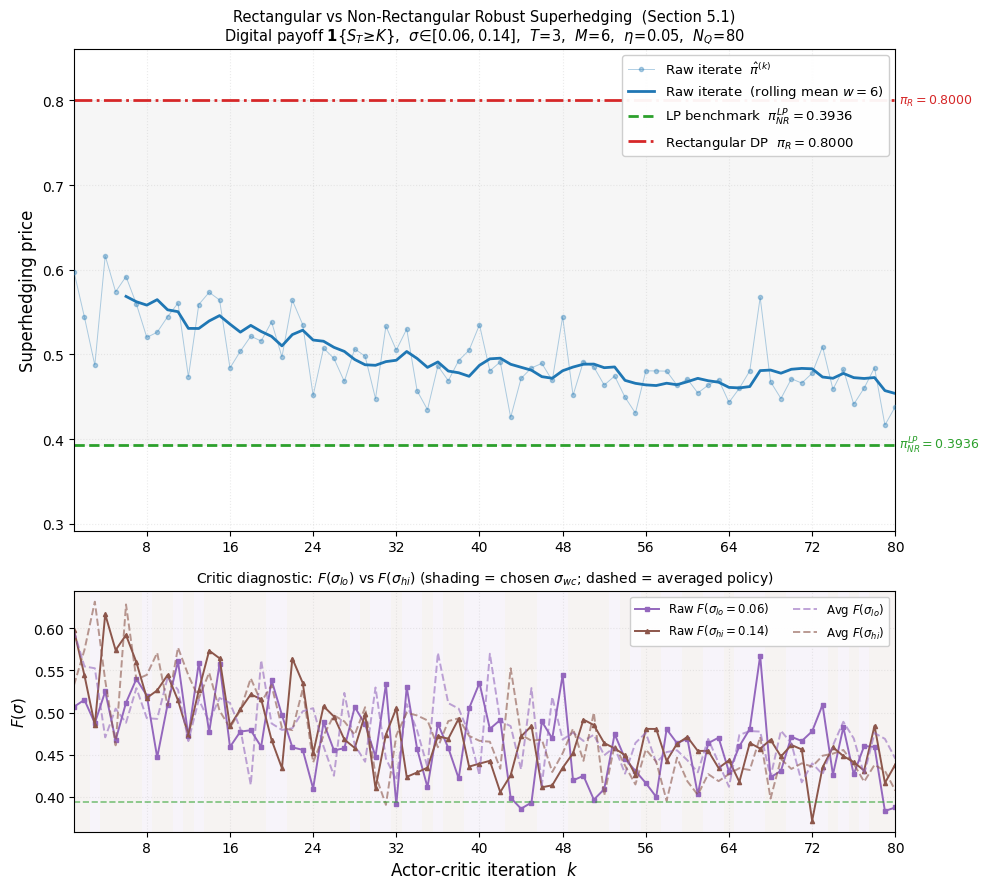

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# PLOT  —  two panels
# ═══════════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9),
                                gridspec_kw={"height_ratios": [3, 1.5]})
fig.subplots_adjust(hspace=0.40)

iters   = np.arange(1, N_AC_ITERS + 1)
raw_arr = np.array(raw_vals)
avg_arr = np.array(avg_vals)
WIN     = max(5, N_AC_ITERS // 12)
rolling = np.convolve(raw_arr, np.ones(WIN) / WIN, mode="valid")
roll_x  = iters[WIN - 1:]
gap     = abs(rect_price - lp_price)

# ── Panel 1: convergence ─────────────────────────────────────────────────────
ax1.plot(iters, raw_arr,
         color="#1f77b4", lw=0.7, marker="o", ms=3, alpha=0.35, zorder=3,
         label=r"Raw iterate  $\hat{\pi}^{(k)}$")
ax1.plot(roll_x, rolling,
         color="#1f77b4", lw=2.0, zorder=4,
         label=rf"Raw iterate  (rolling mean $w={WIN}$)")
ax1.axhline(lp_price,   color="#2ca02c", lw=2.0, ls="--", zorder=2,
            label=rf"LP benchmark  $\pi_{{NR}}^{{LP}} = {lp_price:.4f}$")
ax1.axhline(rect_price, color="#d62728", lw=2.0, ls="-.", zorder=2,
            label=rf"Rectangular DP  $\pi_R = {rect_price:.4f}$")
ax1.axhspan(lp_price, rect_price, alpha=0.07, color="#888888", zorder=1)
ax1.annotate(rf"$\pi_R={rect_price:.4f}$",
             xy=(N_AC_ITERS + 0.4, rect_price), fontsize=9,
             color="#d62728", va="center", annotation_clip=False)
ax1.annotate(rf"$\pi_{{NR}}^{{LP}}={lp_price:.4f}$",
             xy=(N_AC_ITERS + 0.4, lp_price), fontsize=9,
             color="#2ca02c", va="center", annotation_clip=False)
ax1.set_ylabel("Superhedging price", fontsize=12)
ax1.set_title(
    "Rectangular vs Non-Rectangular Robust Superhedging  (Section 5.1)\n"
    r"Digital payoff $\mathbf{1}\{S_T\!\geq\!K\}$,"
    rf"  $\sigma\!\in\![{SIGMA_LO},{SIGMA_HI}]$,"
    rf"  $T\!=\!{T}$,  $M\!=\!{N_SIGMA}$,"
    rf"  $\eta\!=\!{ETA_ACTOR}$,  $N_Q\!=\!{N_MC_Q}$",
    fontsize=10.5)
ax1.set_xlim(1, N_AC_ITERS)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
y_lo = min(np.min(raw_arr), np.min(avg_arr), lp_price) - gap * 0.25
y_hi = max(np.max(raw_arr), np.max(avg_arr), rect_price) + gap * 0.15
ax1.set_ylim(y_lo, y_hi)
ax1.legend(fontsize=9.5, framealpha=0.95, loc="upper right")
ax1.grid(True, alpha=0.25, ls=":")

# ── Panel 2: critic diagnostic ───────────────────────────────────────────────
ax2.plot(iters, F_lo_hist, color="#9467bd", lw=1.4, marker="s", ms=3,
         label=rf"Raw $F(\sigma_{{lo}}={SIGMA_LO})$")
ax2.plot(iters, F_hi_hist, color="#8c564b", lw=1.4, marker="^", ms=3,
         label=rf"Raw $F(\sigma_{{hi}}={SIGMA_HI})$")
ax2.plot(iters, F_lo_avg_hist, color="#9467bd", lw=1.4, ls="--", alpha=0.6,
         label=rf"Avg $F(\sigma_{{lo}})$")
ax2.plot(iters, F_hi_avg_hist, color="#8c564b", lw=1.4, ls="--", alpha=0.6,
         label=rf"Avg $F(\sigma_{{hi}})$")
for k in range(N_AC_ITERS):
    c = "#8c564b" if sigma_hist[k] == SIGMA_HI else "#9467bd"
    ax2.axvspan(k + 0.5, k + 1.5, alpha=0.07, color=c, lw=0)
ax2.axhline(lp_price, color="#2ca02c", lw=1.2, ls="--", alpha=0.6)
ax2.set_xlabel("Actor-critic iteration  $k$", fontsize=12)
ax2.set_ylabel(r"$F(\sigma)$", fontsize=11)
ax2.set_title(
    r"Critic diagnostic: $F(\sigma_{lo})$ vs $F(\sigma_{hi})$"
    " (shading = chosen $\\sigma_{wc}$; dashed = averaged policy)",
    fontsize=10)
ax2.set_xlim(1, N_AC_ITERS)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.legend(fontsize=8.5, framealpha=0.95, loc="upper right", ncol=2)
ax2.grid(True, alpha=0.25, ls=":")

fig.tight_layout()
plt.show()


## Sweeps over horizon $T$ and interval half-width $\delta$

Two parameter sweeps comparing the non-rectangular LP price $\pi_{LP}$ and
the rectangular DP price $\pi_R$:

1. $\pi_{LP}$ vs $\pi_R$ as a function of horizon $T$ (with the volatility interval
   fixed at the notebook value)
2. $\pi_{LP}$ vs $\pi_R$ as a function of interval half-width $\delta$, where
   $\sigma \in [\bar\sigma - \delta, \bar\sigma + \delta]$ with
   $\bar\sigma = (\sigma_{lo} + \sigma_{hi})/2$ held at the notebook midpoint.

Both reuse the LP and rect-DP formulations of cells 13 and 15 via the
self-contained helper `solve_for_params(T_, sigma_lo_, sigma_hi_)` defined
below. Each sweep point rebuilds path data and consistent sets locally; no
module-level state from the main run is mutated.

**Note on $\delta = 0$.** The ambiguity set collapses to the singleton
$\{P^{\bar\sigma}\}$, so non-rectangular and rectangular formulations
coincide and $\pi_{LP} = \pi_R$. This is the natural lower-bound boundary
condition.


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# SWEEP HELPER  —  self-contained (T, sigma_lo, sigma_hi) -> (pi_LP, pi_R)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Rebuilds path data, consistent sets, and reachable price nodes for the given
# parameters, then solves both the non-rectangular LP and the rectangular DP
# using the SAME formulations as cells 13 and 15.
#
# Reuses notebook-level constants:  S0, MU, K_STRIKE, N_SIGMA, A_GRID, PREC, PREC_DP.
# W_GRID is widened locally for large T to keep the wealth-coverage diagnostic happy.
# ─────────────────────────────────────────────────────────────────────────────


def _w_grid_for(T_, sigma_hi_):
    """W_GRID widened to cover all reachable terminal wealth at horizon T_."""
    w_extreme = T_ * sigma_hi_ * float(np.max(np.abs(A_GRID))) * 1.1
    w_extreme = max(w_extreme, 1.0)
    return np.linspace(-w_extreme, w_extreme, max(NW, 31))


def solve_for_params(T_, sigma_lo_, sigma_hi_, verbose=False):
    """
    End-to-end:  build paths, consistent sets, reachable price nodes
    -> solve LP + rect DP.  Returns (pi_LP, pi_R).
    """
    # ─── 1. Local data ───────────────────────────────────────────────────────
    sigma_grid = np.linspace(sigma_lo_, sigma_hi_, N_SIGMA)
    sign_seqs_ = list(itertools.product([-1, 1], repeat=T_))

    paths_, sigma_labels_ = [], []
    for sigma in sigma_grid:
        for signs in sign_seqs_:
            s = [S0]
            for eps in signs:
                s.append(s[-1] + MU + sigma * eps)
            paths_.append(s)
            sigma_labels_.append(sigma)
    paths_        = np.array(paths_)
    sigma_labels_ = np.array(sigma_labels_)
    N_       = len(paths_)
    ds_      = np.diff(paths_, axis=1)
    payoffs_ = (paths_[:, -1] >= K_STRIKE).astype(float)

    # ─── 2. Consistent sets via (sigma_label, prefix) keys ───────────────────
    consistent_ = {}
    for i in range(N_):
        for t in range(T_):
            key_i = (round(float(sigma_labels_[i]), PREC),
                     tuple(np.round(paths_[i, :t + 1], PREC)))
            consistent_[(i, t)] = [
                j for j in range(N_)
                if (round(float(sigma_labels_[j]), PREC),
                    tuple(np.round(paths_[j, :t + 1], PREC))) == key_i
            ]

    # ─── 3. LP benchmark (eq. 21) ────────────────────────────────────────────
    node_map, path_nodes = {}, []
    for i in range(N_):
        row = []
        for t in range(T_):
            key = (t, frozenset(consistent_[(i, t)]))
            if key not in node_map:
                node_map[key] = len(node_map)
            row.append(node_map[key])
        path_nodes.append(row)

    x_var = cp.Variable()
    h_var = cp.Variable(len(node_map))
    cons = []
    for i in range(N_):
        wealth_i = x_var + cp.sum([
            h_var[path_nodes[i][t]] * float(ds_[i, t])
            for t in range(T_)
        ])
        cons.append(wealth_i >= float(payoffs_[i]))

    prob_lp = cp.Problem(cp.Minimize(x_var), cons)
    prob_lp.solve(solver=cp.HIGHS)
    if prob_lp.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(
            f"LP failed: {prob_lp.status}  (T={T_}, sigma in [{sigma_lo_}, {sigma_hi_}])"
        )
    pi_LP = float(x_var.value)

    # ─── 4. Rectangular DP (eq. 25) — exact backward induction ───────────────
    # The notebook A_GRID is [-2, 2] x 13 points; for the sweep we widen it so
    # the rect DP's action constraint does not become binding (the LP uses
    # h in R freely, so a narrow A_GRID would inflate pi_R artificially and
    # mask the true rectangularization gap). 51 points keeps it fast.
    A_GRID_DP = np.linspace(-10.0, 10.0, 51)

    sigmas_dp = [sigma_lo_, sigma_hi_] if sigma_lo_ < sigma_hi_ else [sigma_lo_]

    nodes = {0: {round(S0, PREC_DP)}}
    for t in range(T_):
        nodes[t + 1] = set()
        for s in nodes[t]:
            for sigma in sigmas_dp:
                for eps in [-1, 1]:
                    nodes[t + 1].add(round(s + MU + sigma * eps, PREC_DP))

    V = {s: float(s >= K_STRIKE) for s in nodes[T_]}
    for t in reversed(range(T_)):
        V_new = {}
        for s in nodes[t]:
            V_new[s] = min(
                max(
                    V[round(s + MU + sigma * eps, PREC_DP)] - a * (MU + sigma * eps)
                    for sigma in sigmas_dp
                    for eps   in [-1, 1]
                )
                for a in A_GRID_DP
            )
        V = V_new
        if verbose:
            print(f"      rect DP t={t}: {len(V_new)} price nodes")
    pi_R = float(V[round(S0, PREC_DP)])

    return pi_LP, pi_R


### Plot 1 — prices vs horizon $T$

Volatility interval is held at the notebook values $[\sigma_{lo}, \sigma_{hi}]$.
For each $T \in $ `T_VALUES` the helper enumerates the full path tree and
solves both the non-rectangular LP (eq. 21) and the rectangular DP (eq. 25).

By Proposition 1 of the paper, $\pi_{LP} \le \pi_R$ at every $T$, so the
green curve sits weakly below the red.

**On the non-monotonicity of $\pi_{LP}$ in $T$.** The digital payoff
$\mathbf{1}\{S_T \ge K\}$ is discontinuous, so the LP price depends
sensitively on which terminal prices are close to $K$. Adding a time step
adds new sample paths and shifts terminal prices around the strike, which
can move $\pi_{LP}$ either up or down. This is real model behaviour, not
a discretisation artifact.

**On `A_GRID` widening inside the helper.** The notebook's `A_GRID = [-2, 2]`
is fine for the main run but too narrow for the sweep, where it would clip
the optimal hedge in the rect DP and inflate $\pi_R$ artificially. The
helper widens to `[-10, 10]` for the rect DP only — the LP uses unrestricted
hedge variables in any case.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SWEEP 1:  pi_LP and pi_R vs horizon T   (sigma interval fixed at notebook value)
# ═══════════════════════════════════════════════════════════════════════════════

# Runtime grows quickly with T because path count is N = M * 2^T:
#   T=4 ~ 0.4s   T=6 ~ 6s   T=7 ~ 30s   T=8 ~ 2 min

T_VALUES = [1, 2, 3, 4, 5, 6,7,8,9,10]

t0 = time.time()
lp_by_T, rect_by_T = [], []
for T_ in T_VALUES:
    tt = time.time()
    pi_LP, pi_R = solve_for_params(T_, SIGMA_LO, SIGMA_HI)
    lp_by_T.append(pi_LP)
    rect_by_T.append(pi_R)
    print(f"  T={T_}:  pi_LP = {pi_LP:.5f}   pi_R = {pi_R:.5f}   "
          f"gap = {pi_R - pi_LP:.5f}   ({time.time()-tt:.1f}s)")
print(f"  total: {time.time()-t0:.1f}s")

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T_VALUES, lp_by_T,   "o-", color="#2ca02c", lw=2, ms=7,
        label=r"Non-rectangular LP  $\pi_{NR}^{LP}$")
ax.plot(T_VALUES, rect_by_T, "s-", color="#d62728", lw=2, ms=7,
        label=r"Rectangular DP  $\pi_R$")
ax.fill_between(T_VALUES, lp_by_T, rect_by_T,
                color="#888888", alpha=0.12,
                label=r"gap  $\pi_R - \pi_{NR}^{LP}$")
ax.set_xlabel("Horizon  $T$", fontsize=12)
ax.set_ylabel("Superhedging price", fontsize=12)
ax.set_title(
    "Robust superhedging prices vs horizon\n"
    rf"Digital payoff,  $\sigma\in[{SIGMA_LO},{SIGMA_HI}]$,  $M={N_SIGMA}$",
    fontsize=11)
ax.set_xticks(T_VALUES)
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.savefig("sigma_sweep_T.png", dpi=120)
plt.show()


  T=1:  pi_LP = 0.42857   pi_R = 0.61600   gap = 0.18743   (0.0s)
  T=2:  pi_LP = 0.18367   pi_R = 0.55200   gap = 0.36833   (0.0s)
  T=3:  pi_LP = 0.39359   pi_R = 0.64800   gap = 0.25441   (0.0s)
  T=4:  pi_LP = 0.57351   pi_R = 0.69600   gap = 0.12249   (0.2s)
  T=5:  pi_LP = 0.36788   pi_R = 0.66400   gap = 0.29612   (0.6s)
  T=6:  pi_LP = 0.51476   pi_R = 0.68800   gap = 0.17324   (2.5s)
  T=7:  pi_LP = 0.50978   pi_R = 0.72000   gap = 0.21022   (10.7s)
  T=8:  pi_LP = 0.47279   pi_R = 0.71200   gap = 0.23921   (47.5s)


### Plot 2 — prices vs interval half-width $\delta$

Horizon $T$ is held at the notebook value. We center the volatility interval
at $\bar\sigma = (\sigma_{lo} + \sigma_{hi})/2$ from the main run and sweep
the half-width:
$\sigma \in [\bar\sigma - \delta, \bar\sigma + \delta]$ with
$\delta \in $ `DELTA_VALUES`.

Unlike the Wasserstein finite-support example — where $\pi_{LP}$ was flat in
$\rho$ — here $\pi_{LP}$ is *not* flat in $\delta$: widening the interval
adds new $\sigma$ values to the discretised ambiguity set, hence new paths
to the LP support, so both prices respond.

At $\delta = 0$ the ambiguity set collapses to the singleton $\{P^{\bar\sigma}\}$
and the gap should vanish. With the widened action grid used by the helper,
the residual gap at $\delta = 0$ is just numerical (a tiny `A_GRID_DP`
discretisation residual on the rect DP side).


  delta=0.000  (sigma in [0.100, 0.100]):  pi_LP = 0.35200   pi_R = 0.37600   gap = 0.02400   (0.1s)
  delta=0.010  (sigma in [0.090, 0.110]):  pi_LP = 0.36514   pi_R = 0.45600   gap = 0.09086   (0.0s)
  delta=0.020  (sigma in [0.080, 0.120]):  pi_LP = 0.37616   pi_R = 0.52000   gap = 0.14384   (0.0s)
  delta=0.030  (sigma in [0.070, 0.130]):  pi_LP = 0.38553   pi_R = 0.70000   gap = 0.31447   (0.0s)
  delta=0.040  (sigma in [0.060, 0.140]):  pi_LP = 0.39359   pi_R = 0.64800   gap = 0.25441   (0.0s)
  delta=0.050  (sigma in [0.050, 0.150]):  pi_LP = 0.40059   pi_R = 0.65200   gap = 0.25141   (0.0s)
  total: 0.3s


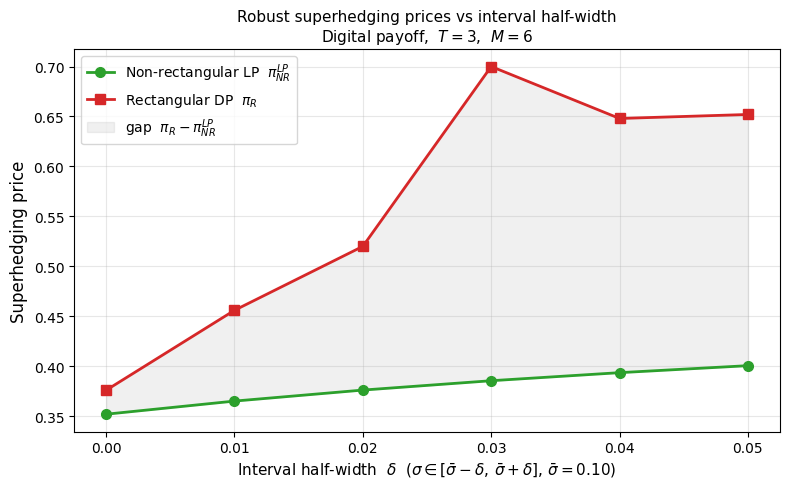

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SWEEP 2:  pi_LP and pi_R vs interval half-width  (T fixed at notebook value)
# ═══════════════════════════════════════════════════════════════════════════════

SIGMA_BAR    = 0.5 * (SIGMA_LO + SIGMA_HI)         # interval midpoint
DELTA_VALUES = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06,0.07]  # interval half-widths

t0 = time.time()
lp_by_D, rect_by_D = [], []
for delta in DELTA_VALUES:
    sigma_lo_ = SIGMA_BAR - delta
    sigma_hi_ = SIGMA_BAR + delta
    tt = time.time()
    pi_LP, pi_R = solve_for_params(T, sigma_lo_, sigma_hi_)
    lp_by_D.append(pi_LP)
    rect_by_D.append(pi_R)
    print(f"  delta={delta:.3f}  (sigma in [{sigma_lo_:.3f}, {sigma_hi_:.3f}]):"
          f"  pi_LP = {pi_LP:.5f}   pi_R = {pi_R:.5f}   "
          f"gap = {pi_R - pi_LP:.5f}   ({time.time()-tt:.1f}s)")
print(f"  total: {time.time()-t0:.1f}s")

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(DELTA_VALUES, lp_by_D,   "o-", color="#2ca02c", lw=2, ms=7,
        label=r"Non-rectangular LP  $\pi_{NR}^{LP}$")
ax.plot(DELTA_VALUES, rect_by_D, "s-", color="#d62728", lw=2, ms=7,
        label=r"Rectangular DP  $\pi_R$")
ax.fill_between(DELTA_VALUES, lp_by_D, rect_by_D,
                color="#888888", alpha=0.12,
                label=r"gap  $\pi_R - \pi_{NR}^{LP}$")
ax.set_xlabel(r"Interval half-width  $\delta$  "
              rf"($\sigma\in[\bar\sigma-\delta,\,\bar\sigma+\delta]$, "
              rf"$\bar\sigma={SIGMA_BAR:.2f}$)", fontsize=11)
ax.set_ylabel("Superhedging price", fontsize=12)
ax.set_title(
    "Robust superhedging prices vs interval half-width\n"
    rf"Digital payoff,  $T={T}$,  $M={N_SIGMA}$",
    fontsize=11)
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.savefig("sigma_sweep_delta.png", dpi=120)
plt.show()
